# Activity scoring of senescence marker genes 
#### GSVA: has mutiplem methods, one is z-score: To generate a score for each cell/sample, the z-scored expression values were filtered for the genes of interest, converted to indicate concordance or discordance with the direction of change in the gene set (includes directionality metadata), and averaged. A positive resulting score indicates a similar expression pattern to the gene-set signature compared to the other cells/samples in the data set

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import GSVA
import matplotlib.pyplot as plt
import numpy as np


In [3]:
def calculate_senescence_score(data, up_genes=None, down_genes=None, method='zscore'):
    """
    Calculate senescence signature scores for each sample based on DEGs from gene-sets
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame with genes as rows and samples as columns (first column should be 'NAME' or gene names)
    up_genes : list, optional
        Genes upregulated in senescent cells (default: None)
    down_genes : list, optional
        Genes downregulated in senescent cells (default: None)
    method : str, optional
        Scoring method ('zscore' or 'gsva'). Default is 'zscore'
        
    Returns:
    --------
    scores_df : pd.DataFrame
        DataFrame with sample names as index and 'senescence_score' as column
    """
    if up_genes is None and down_genes is None:
        raise ValueError("At least one of up_genes or down_genes must be provided")
    
    # Set index to gene names if not already done
    if 'NAME' in data.columns:
        data = data.set_index('NAME')
    if 'Description' in data.columns:
        data = data.drop('Description', axis=1)
    
    # Check which genes are present in the expression data
    available_genes = set(data.index)
    
    # Process up-regulated genes
    if up_genes is not None:
        up_genes_set = set(up_genes)
        up_genes = list(up_genes_set.intersection(available_genes))
        print(f"Using {len(up_genes)} upregulated genes")
    
    # Process down-regulated genes
    if down_genes is not None:
        down_genes_set = set(down_genes)
        down_genes = list(down_genes_set.intersection(available_genes))
        print(f"Using {len(down_genes)} downregulated genes")
    
    # Check if we have enough genes to proceed
    if (up_genes is None or len(up_genes) == 0) and (down_genes is None or len(down_genes) == 0):
        raise ValueError("No genes from the gene sets were found in the expression data")
    
    # Rest of the function remains the same...
    sample_names = data.columns
    expr_matrix = data.select_dtypes(include=[np.number])
    
    # Z-standardize the expression values across samples
    z_standardized = (expr_matrix - expr_matrix.mean(axis=1).values.reshape(-1, 1)) / \
                    expr_matrix.std(axis=1).values.reshape(-1, 1)
    
    # Calculate scores for each sample
    scores = pd.Series(0, index=sample_names)
    
    # Calculate total gene set size for normalization
    total_genes = 0
    if up_genes:
        total_genes += len(up_genes)
    if down_genes:
        total_genes += len(down_genes)
    
    # Calculate combined score with size normalization
    if up_genes:
        up_score = z_standardized.loc[up_genes].sum()
        scores += up_score
    
    if down_genes:
        down_score = z_standardized.loc[down_genes].sum()
        scores -= down_score  # Subtract because these are down-regulated
    
    # Normalize by square root of gene set size
    scores = scores / np.sqrt(total_genes)
    
    # Final z-score normalization across samples
    scores = (scores - scores.mean()) / scores.std()
    
    # Convert to DataFrame with meaningful column name
    scores_df = pd.DataFrame(scores, columns=['senescence_score'])
    
    return scores_df

In [4]:
def map_sample_to_category(sample_name):
    """Map sample names to their experimental categories"""
    if sample_name in ['AV01', 'AV02', 'AV03', 'AV04', 'AV05']:
        return 'Ctrl Low-Fat diet'
    elif sample_name in ['AV06', 'AV07', 'AV08', 'AV09', 'AV10']:
        return 'Trf2 KO Low-Fat diet'
    elif sample_name in ['AV11', 'AV12', 'AV13', 'AV14', 'AV15']:
        return 'Ctrl Western diet'
    elif sample_name in ['AV16', 'AV17', 'AV18', 'AV19', 'AV20']:
        return 'Trf2 KO Western diet'
    return None

In [10]:
data_dir = '/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/'
sensig_geneset = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SenSig_DEGs.csv'
fridman_down_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_down_orthologs.csv'
fridman_up_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_up_orthologs.csv'
senmayo_geneset = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt'
cell_age_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/cellAge_orthologs.csv'

In [6]:
counts = pd.read_csv(os.path.join(data_dir, 'Trf2_Liver_NormCounts_GSEA.gct.txt'), sep='\t', skiprows=2)
expr_df = counts.set_index('NAME')
expr_df = expr_df.drop('Description', axis=1)
expr_df = expr_df.select_dtypes(include=[np.number])
expr_df = expr_df.dropna()  # Remove rows with NaN values
display(expr_df.head())

,AV01,AV02,AV03,AV04,AV05,AV06,AV07,AV08,AV09,AV10,AV11,AV12,AV13,AV14,AV15,AV16,AV17,AV18,AV19,AV20
NAME,,,,,,,,,,,,,,,,,,,,
Xkr4,4.202855,0.000000,0.000000,0.000000,5.489411,0.701450,3.115962,0.000000,0.000000,1.242640,0.000000,0.000000,0.000000,0.000000,0.000000,1.030429,1.642052,0.000000,0.000000,0.781083
Sox17,104.020668,68.775083,40.865415,66.229103,112.532935,65.234839,41.753890,22.378785,36.146543,57.161443,35.110845,77.113697,34.697691,77.299154,32.474227,69.038745,38.588215,25.167334,75.172195,53.894700
Mrpl15,799.593217,741.977338,1061.298871,837.755151,796.879567,824.203605,1042.600871,1112.053462,1459.572458,884.759722,918.935553,823.714489,965.752406,784.883722,875.756567,771.791345,1004.935644,1039.201182,818.875780,712.347336
Lypla1,3446.341331,3227.138511,1094.952743,1937.846361,2074.082640,3115.840354,2166.839945,587.873463,575.851815,1656.439199,2242.251179,3189.702914,739.253588,2547.304444,2159.012302,3899.143454,1620.705034,557.875912,2234.117643,2814.240627
LOC118567656,3.152141,5.290391,0.000000,0.000000,0.000000,2.104350,1.246385,2.582167,0.000000,1.242640,3.632156,4.673557,0.000000,0.000000,2.095111,3.091287,0.821026,0.000000,4.009184,2.343248


#### SenSig

In [7]:
#SenSig
sensig_genes = pd.read_csv(sensig_geneset, skiprows=1)
print(sensig_genes.head())
sensig_up_genes = sensig_genes[sensig_genes['logFC'] > 0]['Gene'].tolist()  
sensig_down_genes = sensig_genes[sensig_genes['logFC'] < 0]['Gene'].tolist()
print(len(sensig_up_genes))
print(len(sensig_down_genes))


      Gene     logFC    logCPM           F        PValue           FDR
0  Aldh1a3 -1.537131  5.312493  317.399525  2.000000e-11  2.250000e-07
1   Card10 -1.329801  6.905892  308.235873  2.460000e-11  2.250000e-07
2   Errfi1 -1.277384  9.671747  285.153969  4.270000e-11  2.610000e-07
3      Tek -1.774617  8.228041  240.112909  1.430000e-10  6.560000e-07
4     Car8 -2.359974  5.802668  203.895757  4.490000e-10  1.640000e-06
8567
9069


#### Fridman

In [11]:
#Fridman gene sets
fridman_down_orthologs = pd.read_csv(fridman_down_orthologs, sep=',', header=0)['ortholog_name'].tolist()
fridman_up_orthologs = pd.read_csv(fridman_up_orthologs, sep=',', header=0)['ortholog_name'].tolist()
display(fridman_down_orthologs[0:5])
display(fridman_up_orthologs[0:5])


['Aldh1a7', 'Aldh1a1', 'Bmi1', 'Ccn4', 'Ccnb1']

#### SenMayo

In [12]:
#SenMayo
senmayo_genes = pd.read_csv(senmayo_geneset, sep='\t', header=None)
senmayo_up_genes = senmayo_genes.iloc[0, 2:].dropna().tolist()
display(senmayo_up_genes[0:5])


['Acvr1b', 'Ang', 'Angpt1', 'Angptl4', 'Areg']

#### CellAge

In [13]:
cellage_orthologs = pd.read_csv(cell_age_orthologs, sep=',', header=0)['ortholog_name'].tolist()
display(cellage_orthologs[0:5])


['Aak1', 'Abcb1b', 'Abcb1a', 'Abcc6', 'Abi3']

## Get the senescence scores

In [14]:
#SenSig
sensig_scores = calculate_senescence_score(expr_df, up_genes=sensig_up_genes, down_genes=sensig_down_genes)
sensig_up_scores = calculate_senescence_score(expr_df, up_genes=sensig_up_genes)
sensig_down_scores = calculate_senescence_score(expr_df, down_genes=sensig_down_genes)
# add category to the sample names
sensig_scores['category'] = sensig_scores.index.map(map_sample_to_category)
sensig_up_scores['category'] = sensig_up_scores.index.map(map_sample_to_category)
sensig_down_scores['category'] = sensig_down_scores.index.map(map_sample_to_category)


Using 7088 upregulated genes
Using 7353 downregulated genes
Using 7088 upregulated genes
Using 7353 downregulated genes


In [15]:
#Fridman
fridman_scores = calculate_senescence_score(expr_df, up_genes=fridman_up_orthologs, down_genes=fridman_down_orthologs)
fridman_up_scores = calculate_senescence_score(expr_df, up_genes=fridman_up_orthologs)
fridman_down_scores = calculate_senescence_score(expr_df, down_genes=fridman_down_orthologs)
fridman_up_scores['category'] = fridman_up_scores.index.map(map_sample_to_category)
fridman_down_scores['category'] = fridman_down_scores.index.map(map_sample_to_category)
fridman_scores['category'] = fridman_scores.index.map(map_sample_to_category)

Using 82 upregulated genes
Using 13 downregulated genes
Using 82 upregulated genes
Using 13 downregulated genes


In [21]:
#SenMayo
senmayo_scores = calculate_senescence_score(expr_df, up_genes=senmayo_up_genes)
senmayo_scores['category'] = senmayo_scores.index.map(map_sample_to_category)


Using 106 upregulated genes


## Plotting

In [16]:
def plot_scores_scatter(scores_df, category_colors, title=None, ylabel=None):
    """
    Create a scatter plot of senescence scores with colored labels by category
    
    Parameters:
    -----------
    scores_df : pandas DataFrame
        DataFrame containing scores and categories
    category_colors : dict
        Dictionary mapping categories to colors
    title : str, optional
        Custom title for the plot (e.g., "Fridman Senescence Signature Scores")
    ylabel : str, optional
        Custom y-axis label (e.g., "Fridman Score")
    """
    plt.figure(figsize=(12, 6))
    
    # Sort by score for clustering effect
    scores_sorted = scores_df.sort_values('senescence_score')
    
    # Create scatter plot
    plt.scatter(range(len(scores_sorted)), 
               scores_sorted['senescence_score'],
               alpha=0)  # Make points invisible
    
    # Add colored labels
    for i, (idx, row) in enumerate(scores_sorted.iterrows()):
        plt.annotate(idx,  # sample name
                    (i, row['senescence_score']),
                    color=category_colors[row['category']],
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center',
                    fontsize=10)
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], 
                                color=color, 
                                label=cat, 
                                marker='o')
                      for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements, 
              loc='center left', 
              bbox_to_anchor=(1, 0.5))
    
    # Customize plot
    plt.grid(True, alpha=0.3)
    plt.xlabel('Samples (ordered by score)')
    plt.ylabel(ylabel if ylabel else 'Senescence Score')
    plt.title(title if title else 'Senescence Scores Distribution')
    plt.xticks([])
    
    plt.tight_layout()
    plt.show()


In [17]:
def plot_scores_by_category(scores_df, category_colors, title=None, ylabel=None):
    """
    Create a box plot with category-matched colors, statistics, and significance indicators
    
    Parameters:
    -----------
    scores_df : pandas DataFrame
        DataFrame containing scores and categories
    category_colors : dict
        Dictionary mapping categories to colors
    title : str, optional
        Custom title for the plot (e.g., "Fridman Senescence Signature Scores")
    ylabel : str, optional
        Custom y-axis label (e.g., "Fridman Score")
    """
    import scipy.stats as stats
    plt.figure(figsize=(12, 8))
    
    # Create box plot with category colors
    ax = sns.boxplot(x='category', y='senescence_score', data=scores_df,
                    palette=category_colors, width=0.5)
    
    # Add individual points
    sns.swarmplot(x='category', y='senescence_score', data=scores_df,
                 color='0.2', alpha=0.6)
    
    # Statistical tests
    categories = scores_df['category'].unique()
    groups = [scores_df[scores_df['category'] == cat]['senescence_score'].values 
             for cat in categories]
    
    # Calculate y-axis limits for plotting
    y_max = scores_df['senescence_score'].max()
    y_min = scores_df['senescence_score'].min()
    y_range = y_max - y_min
    
    try:
        # Perform ANOVA
        f_stat, p_value = stats.f_oneway(*groups)
        
        # Define pairs for comparison
        pairs = [
            ('Ctrl Low-Fat diet', 'Trf2 KO Low-Fat diet'),
            ('Ctrl Western diet', 'Trf2 KO Western diet'),
            ('Ctrl Low-Fat diet', 'Ctrl Western diet'),
            ('Trf2 KO Low-Fat diet', 'Trf2 KO Western diet')
        ]
        
        # Add significance bars
        for idx, (cat1, cat2) in enumerate(pairs):
            if cat1 in categories and cat2 in categories:
                group1 = scores_df[scores_df['category'] == cat1]['senescence_score']
                group2 = scores_df[scores_df['category'] == cat2]['senescence_score']
                
                if len(group1) > 1 and len(group2) > 1:
                    stat, p = stats.ttest_ind(group1, group2)
                    
                    # Get x-coordinates
                    x1 = list(categories).index(cat1)
                    x2 = list(categories).index(cat2)
                    
                    # Calculate y position
                    y = y_max + (idx + 1) * (y_range * 0.1)
                    
                    # Add significance annotation if p < 0.05
                    if p < 0.05:
                        plt.plot([x1, x1, x2, x2], 
                               [y, y + y_range*0.02, y + y_range*0.02, y],
                               color='black', lw=1)
                        
                        sig = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
                        plt.text((x1 + x2) / 2, y + y_range*0.02, 
                               f'{sig}\np={p:.3f}',
                               ha='center', va='bottom')
        
        # Add ANOVA result
        plt.text(0.02, 0.98, 
                f'One-way ANOVA:\nF={f_stat:.2f}, p={p_value:.3f}',
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(facecolor='white', alpha=0.8))
        
    except Exception as e:
        print(f"Error in statistical analysis: {str(e)}")
    
    # Add mean ± std annotations
    for i, cat in enumerate(categories):
        stats_values = scores_df[scores_df['category'] == cat]['senescence_score']
        mean = stats_values.mean()
        std = stats_values.std()
        n = len(stats_values)
        
        # Add text below the plot
        plt.text(i, y_min - y_range*0.1,
                f'n = {n}\nMean = {mean:.2f}\nSTD = {std:.2f}',
                ha='center', va='top',
                color=category_colors[cat],
                fontsize=9)
    
    # Customize plot
    plt.title(title if title else 'Senescence Scores by Category')
    plt.xlabel('')
    plt.ylabel(ylabel if ylabel else 'Senescence Score')
    plt.xticks(rotation=45, ha='right')
    
    # Adjust y-axis limits to show all annotations
    plt.ylim(y_min - y_range*0.3, y_max + y_range*0.5)
    
    plt.tight_layout()
    plt.show()

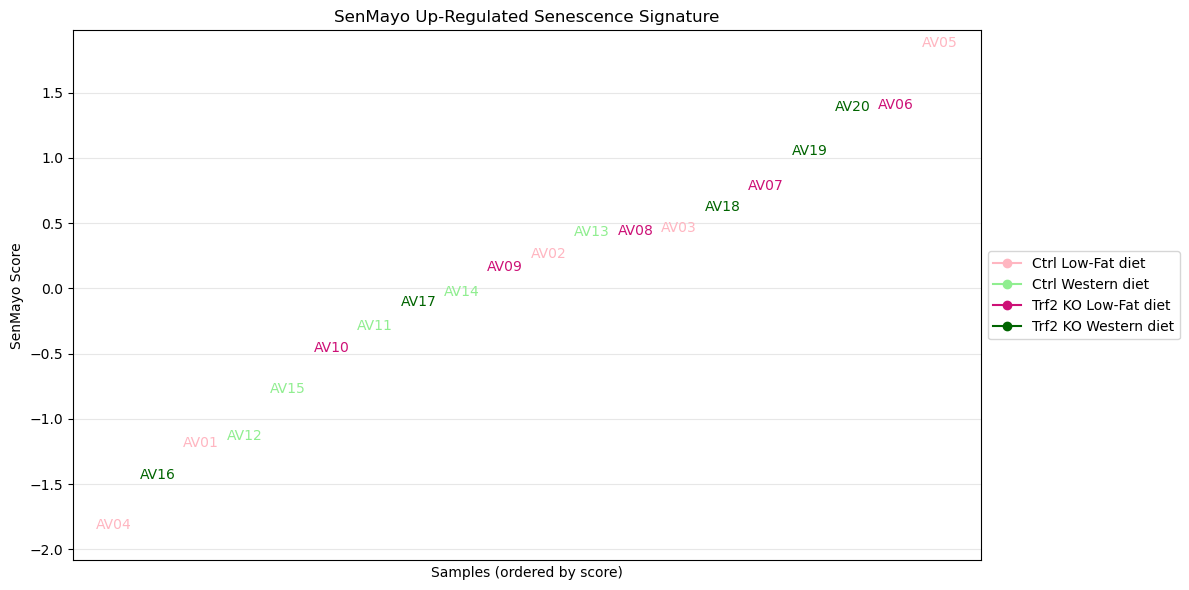

/tmp/ipykernel_19556/2388108358.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='category', y='senescence_score', data=scores_df,


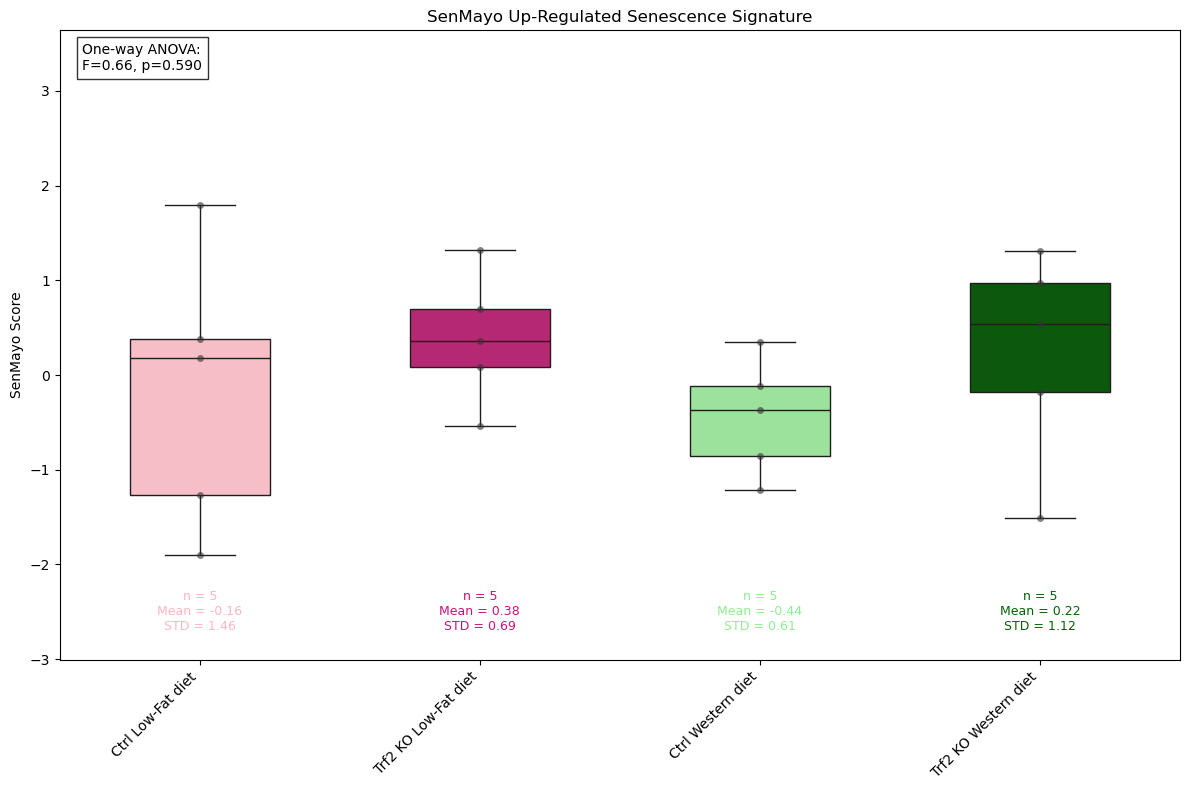

In [22]:
custom_colors = {
    'Ctrl Low-Fat diet': '#FFB6C1',      # Light pink/salmon
    'Ctrl Western diet': '#90EE90',       # Light green
    'Trf2 KO Low-Fat diet': '#CD1076',   # Deep pink
    'Trf2 KO Western diet': '#006400'     # Dark green
}

#Fridman
plot_scores_scatter(senmayo_scores, 
                   category_colors=custom_colors,
                   title="SenMayo Up-Regulated Senescence Signature",
                   ylabel="SenMayo Score")

plot_scores_by_category(senmayo_scores, 
                       category_colors=custom_colors,
                       title="SenMayo Up-Regulated Senescence Signature",
                       ylabel="SenMayo Score")
